In [1]:
# --- Cell 1: Imports ---
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
from src.splits import stratified_split, stratified_kfold
from src.experiments import run_cross_validation_sweep, run_scaling_experiment

In [2]:
# --- Cell 2: Rebuild Dev Set ---
# Re-load and re-split using the same seed as 02_evaluation.ipynb
# so X_dev / y_dev are identical to what was used there.
df_clean = pd.read_csv('../data/titanic_cleaned.csv')
X = df_clean.drop(columns=['survived']).values
y = df_clean['survived'].values

X_train, X_val, X_test, y_train, y_val, y_test = stratified_split(
    X, y,
    train_frac=0.60,
    val_frac=0.20,
    test_frac=0.20,
    seed=42
)

# Dev set = everything except the held-out test set
X_dev = np.vstack((X_train, X_val))
y_dev = np.concatenate((y_train, y_val))

print(f'Dev set shape:             X={X_dev.shape}, y={y_dev.shape}')
print(f'Dev set positive rate:     {y_dev.mean():.4f}')

Dev set shape:             X=(1047, 10), y=(1047,)
Dev set positive rate:     0.3820


In [3]:
# --- Cell 3: Verify Stratified K-Fold (Part 4.1) ---
folds = stratified_kfold(X_dev, y_dev, n_splits=5, random_state=42)

print(f'Total dev positive rate: {y_dev.mean():.4f}\n')

for i, (X_tr_f, y_tr_f, X_val_f, y_val_f) in enumerate(folds):
    print(f'Fold {i+1}:')
    print(f'  Train positive rate: {y_tr_f.mean():.4f}  (n={len(y_tr_f)})')
    print(f'  Val   positive rate: {y_val_f.mean():.4f}  (n={len(y_val_f)})')

Total dev positive rate: 0.3820

Fold 1:
  Train positive rate: 0.3823  (n=837)
  Val   positive rate: 0.3810  (n=210)
Fold 2:
  Train positive rate: 0.3823  (n=837)
  Val   positive rate: 0.3810  (n=210)
Fold 3:
  Train positive rate: 0.3819  (n=838)
  Val   positive rate: 0.3828  (n=209)
Fold 4:
  Train positive rate: 0.3819  (n=838)
  Val   positive rate: 0.3828  (n=209)
Fold 5:
  Train positive rate: 0.3819  (n=838)
  Val   positive rate: 0.3828  (n=209)


Running 5-fold cross-validation sweep over k...


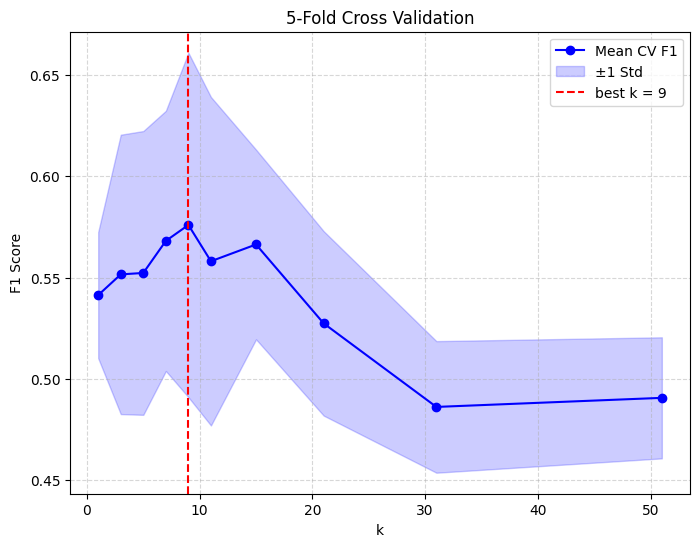


Best k by mean CV F1: k = 9  (mean F1 = 0.5760)


In [4]:
# --- Cell 4: CV Sweep (Part 4.2) ---
print('Running 5-fold cross-validation sweep over k...')
best_cv_k, best_cv_f1 = run_cross_validation_sweep(X_dev, y_dev, n_splits=5)

print(f'\nBest k by mean CV F1: k = {best_cv_k}  (mean F1 = {best_cv_f1:.4f})')

In [5]:
# --- Cell 5: Scaling Experiment (Part 4.5) ---
print(f'Running scaling experiment with best_cv_k = {best_cv_k}...')
scaled_cv_f1 = run_scaling_experiment(X_dev, y_dev, best_cv_k, n_splits=5)

print('-' * 40)
print(f'Unscaled mean CV F1: {best_cv_f1:.4f}')
print(f'Scaled   mean CV F1: {scaled_cv_f1:.4f}')
print(f'Lift:                {scaled_cv_f1 - best_cv_f1:+.4f}')
print('-' * 40)

Running scaling experiment with best_cv_k = 9...
----------------------------------------
Unscaled mean CV F1: 0.5760
Scaled   mean CV F1: 0.6996
Lift:                +0.1236
----------------------------------------
